In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('Sales2.csv')

In [3]:
data['Date'] = pd.to_datetime(data['Date'])
data.head(5)

,Date,Order,Item Purchased,Sales,Review Rating,Shipping Type,Discount Applied,Promo Code Used
0,2023-01-01,3164576526,Skirt,2,3.1,Express,Yes,Yes
1,2023-01-02,3165351216,Shirt,2,3.1,Express,Yes,Yes
2,2023-01-02,12-10986-29949,Blouse,4,3.1,Free Shipping,Yes,Yes
3,2023-01-02,3166515488,Shirt,5,3.5,Next Day Air,Yes,Yes
4,2023-01-02,3166572296-1,Shirt,2,2.7,Free Shipping,Yes,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1653 non-null   datetime64[ns]
 1   Order             1653 non-null   object        
 2   Item Purchased    1653 non-null   object        
 3   Sales             1653 non-null   int64         
 4   Review Rating     1653 non-null   float64       
 5   Shipping Type     1653 non-null   object        
 6   Discount Applied  1653 non-null   object        
 7   Promo Code Used   1653 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 103.4+ KB


In [5]:
#sumsale_by_product
data = data.groupby(['Date','Item Purchased'])['Sales'].sum()
# Chuyển Series thành DataFrame
data = pd.DataFrame(data, columns=['Sales'])
# new_data_df
data.head(20)

Sales
Date       Item Purchased       
2023-01-01 Skirt               2
2023-01-02 Blouse            134
           Dress              13
           Shirt              65
           Skirt               5
2023-01-03 Blouse             57
           Dress               6
2023-01-04 Blouse             92
           Dress               8
           Shirt              40
           Skirt               3
2023-01-05 Blouse             59
           Dress              42
           Shirt              21
2023-01-06 Blouse             50
           Dress              10
           Shirt              26
           Skirt               3
2023-01-08 Blouse            226
           Dress              24

In [6]:
#change index của dataframe
data=data.reset_index()
data = data.set_index('Date')

In [7]:
true_item=['Blouse']
#file mã
data = data.loc[data['Item Purchased'].isin(true_item)]

In [8]:
import copy
dataconcate=copy.copy(data)

In [9]:
# Preprocess the data
scaler = MinMaxScaler()
data['Sales'] = scaler.fit_transform(data['Sales'].values.reshape(-1, 1))
data.head(5)

,Item Purchased,Sales
Date,,
2023-01-02,Blouse,0.589286
2023-01-03,Blouse,0.245536
2023-01-04,Blouse,0.401786
2023-01-05,Blouse,0.254464
2023-01-06,Blouse,0.214286


In [10]:
# Split the data into training and testing sets
train_size = int(len(data) * 0.7)
train_data, test_data = data[:train_size], data[train_size:]

In [11]:
# Create sequences for LSTM
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length):
        sequence = data[i:i+sequence_length]
        target = data[i+sequence_length:i+sequence_length+1]
        sequences.append((sequence, target))
    return sequences

sequence_length = 10
train_sequences = create_sequences(train_data['Sales'], sequence_length)
test_sequences = create_sequences(test_data['Sales'], sequence_length)

X_train, y_train = np.array([seq[0] for seq in train_sequences]), np.array([seq[1] for seq in train_sequences])
X_test, y_test = np.array([seq[0] for seq in test_sequences]), np.array([seq[1] for seq in test_sequences])


In [12]:
# Build the LSTM model
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


In [13]:
# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

Epoch 1/50
1/1 [==============================] - 3s 3s/step - loss: 0.1117
Epoch 2/50
1/1 [==============================] - 0s 21ms/step - loss: 0.1037
Epoch 3/50
1/1 [==============================] - 0s 20ms/step - loss: 0.0960
Epoch 4/50
1/1 [==============================] - 0s 18ms/step - loss: 0.0888
Epoch 5/50
1/1 [==============================] - 0s 18ms/step - loss: 0.0818
Epoch 6/50
1/1 [==============================] - 0s 18ms/step - loss: 0.0751
Epoch 7/50
1/1 [==============================] - 0s 17ms/step - loss: 0.0686
Epoch 8/50
1/1 [==============================] - 0s 19ms/step - loss: 0.0623
Epoch 9/50
1/1 [==============================] - 0s 20ms/step - loss: 0.0563
Epoch 10/50
1/1 [==============================] - 0s 18ms/step - loss: 0.0507
Epoch 11/50
1/1 [==============================] - 0s 18ms/step - loss: 0.0453
Epoch 12/50
1/1 [==============================] - 0s 18ms/step - loss: 0.0404
Epoch 13/50
1/1 [==============================] - 0s 19ms/step

In [14]:
# Inverse transform the scaled predictions to get actual sales values
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

In [15]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 63.279340759104024
Test RMSE: 35.32642248671367


In [16]:
print(test_predictions)

[[36.30212 ]
 [35.107914]
 [34.550938]]


In [17]:
import tensorflow as tf
# Predict sales for future time steps
time_steps = sequence_length
future_time_steps = 60
future_data = data['Sales'].values[-time_steps:].reshape(1, -1, 1)
future_data = future_data.reshape(1, time_steps, 1)
future_predictions = []

for _ in range(future_time_steps):
    next_prediction = model.predict(tf.convert_to_tensor(future_data))
    future_predictions.append(next_prediction[0, 0])
    future_data = np.append(future_data[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Inverse transform the future predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future timestamps
last_timestamp = data.index[-1]
future_timestamps = pd.date_range(start=last_timestamp, periods=future_time_steps+1, freq=data.index.freq)



1/1 [==============================] - 0s 57ms/step


In [18]:
print(future_predictions)

[[33.731552]
 [35.251614]
 [36.316254]
 [37.986763]
 [39.66664 ]
 [41.314503]
 [42.89622 ]
 [44.338646]
 [45.879555]
 [47.34703 ]
 [48.72348 ]
 [49.370705]
 [49.973328]
 [50.53775 ]
 [51.046154]
 [51.49915 ]
 [51.897556]
 [52.245422]
 [52.54812 ]
 [52.80446 ]
 [53.019226]
 [53.194473]
 [53.349552]
 [53.48587 ]
 [53.604717]
 [53.70768 ]
 [53.796432]
 [53.87281 ]
 [53.938393]
 [53.994736]
 [54.04309 ]
 [54.084724]
 [54.120884]
 [54.15225 ]
 [54.179382]
 [54.202774]
 [54.22295 ]
 [54.24035 ]
 [54.25534 ]
 [54.268284]
 [54.27944 ]
 [54.289093]
 [54.29744 ]
 [54.304634]
 [54.31085 ]
 [54.316216]
 [54.32086 ]
 [54.324875]
 [54.32832 ]
 [54.331303]
 [54.333874]
 [54.336105]
 [54.33802 ]
 [54.339687]
 [54.341125]
 [54.342365]
 [54.343422]
 [54.34435 ]
 [54.345142]
 [54.345837]]


In [19]:
future_timestamps=future_timestamps[1:]
future_timestamps

DatetimeIndex(['2023-03-21', '2023-03-22', '2023-03-23', '2023-03-24',
               '2023-03-25', '2023-03-26', '2023-03-27', '2023-03-28',
               '2023-03-29', '2023-03-30', '2023-03-31', '2023-04-01',
               '2023-04-02', '2023-04-03', '2023-04-04', '2023-04-05',
               '2023-04-06', '2023-04-07', '2023-04-08', '2023-04-09',
               '2023-04-10', '2023-04-11', '2023-04-12', '2023-04-13',
               '2023-04-14', '2023-04-15', '2023-04-16', '2023-04-17',
               '2023-04-18', '2023-04-19', '2023-04-20', '2023-04-21',
               '2023-04-22', '2023-04-23', '2023-04-24', '2023-04-25',
               '2023-04-26', '2023-04-27', '2023-04-28', '2023-04-29',
               '2023-04-30', '2023-05-01', '2023-05-02', '2023-05-03',
               '2023-05-04', '2023-05-05', '2023-05-06', '2023-05-07',
               '2023-05-08', '2023-05-09', '2023-05-10', '2023-05-11',
               '2023-05-12', '2023-05-13', '2023-05-14', '2023-05-15',
      

In [20]:
sale2nextmonth=pd.DataFrame(future_predictions,columns=['sale_prediction'], index=future_timestamps)

csv_file_path = 'predictsale2nextmonth_blouse.csv'
# Export the DataFrame to a CSV file
sale2nextmonth.to_csv(csv_file_path)

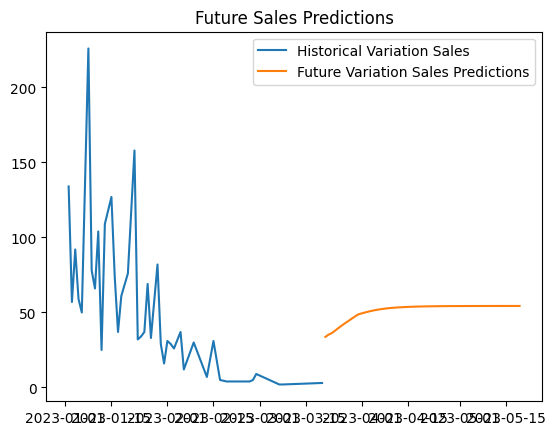

In [21]:
# Plot the results
plt.plot(data.index, scaler.inverse_transform(data['Sales'].values.reshape(-1, 1)), label='Historical Variation Sales')
plt.plot(future_timestamps, future_predictions, label='Future Variation Sales Predictions')
plt.legend()
plt.title('Future Sales Predictions')
plt.show()

In [22]:
print(sale2nextmonth)

            sale_prediction
2023-03-21        33.731552
2023-03-22        35.251614
2023-03-23        36.316254
2023-03-24        37.986763
2023-03-25        39.666641
2023-03-26        41.314503
2023-03-27        42.896221
2023-03-28        44.338646
2023-03-29        45.879555
2023-03-30        47.347031
2023-03-31        48.723480
2023-04-01        49.370705
2023-04-02        49.973328
2023-04-03        50.537750
2023-04-04        51.046154
2023-04-05        51.499149
2023-04-06        51.897556
2023-04-07        52.245422
2023-04-08        52.548119
2023-04-09        52.804459
2023-04-10        53.019226
2023-04-11        53.194473
2023-04-12        53.349552
2023-04-13        53.485870
2023-04-14        53.604717
2023-04-15        53.707680
2023-04-16        53.796432
2023-04-17        53.872810
2023-04-18        53.938393
2023-04-19        53.994736
2023-04-20        54.043091
2023-04-21        54.084724
2023-04-22        54.120884
2023-04-23        54.152248
2023-04-24        54

In [23]:
sale6month = pd.concat([dataconcate, sale2nextmonth],axis=1)
sale6month

,Item Purchased,Sales,sale_prediction
2023-01-02,Blouse,134.0,NaN
2023-01-03,Blouse,57.0,NaN
2023-01-04,Blouse,92.0,NaN
2023-01-05,Blouse,59.0,NaN
2023-01-06,Blouse,50.0,NaN
...,...,...,...
2023-05-15,NaN,NaN,54.342365
2023-05-16,NaN,NaN,54.343422
2023-05-17,NaN,NaN,54.344349
2023-05-18,NaN,NaN,54.345142


In [24]:
csv_file_path = 'sale6nextmonth_blouse.csv'

# Export the DataFrame to a CSV file
sale6month.to_csv(csv_file_path)

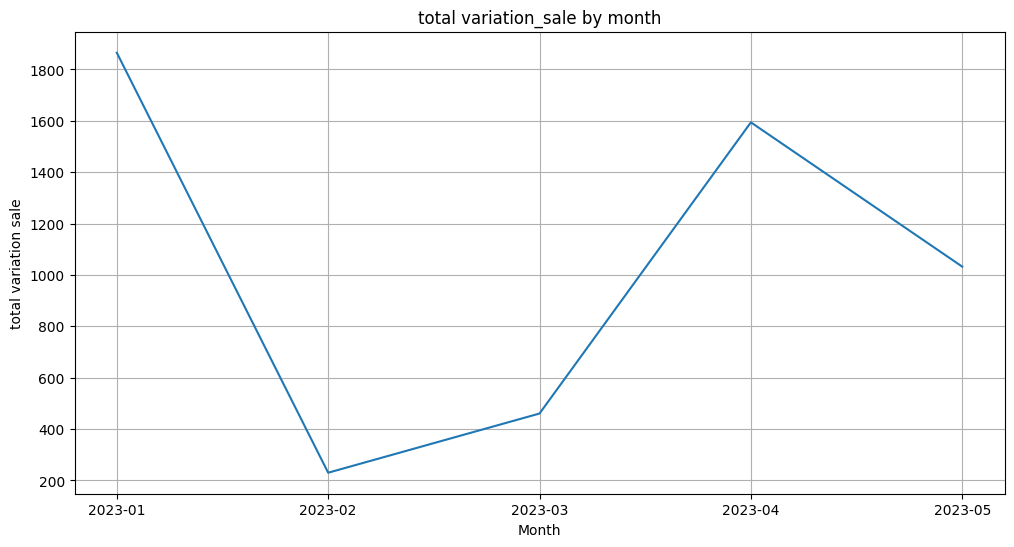

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sale6nextmonth_blouse.csv")
df = df.rename(columns={'Unnamed: 0': 'date'})

for index, row in df.iterrows():
    if pd.isna(df.at[index, "Sales"]):
        df.at[index, "Sales"] = row["sale_prediction"]

# Giả sử bạn có DataFrame 'df' với các cột 'date' và 'variation_sale'
# Cột 'date' có định dạng 'YYYY-MM-DD'

# Tính tổng variation_sale theo tháng
monthly_sales = df.groupby(pd.to_datetime(df['date']).dt.strftime('%Y-%m'))['Sales'].sum().reset_index()

# Đổi tên cột
monthly_sales = monthly_sales.rename(columns={'index': 'month', 'Sales': 'total_variation_sale'})

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["date"], monthly_sales['total_variation_sale'])
plt.title('total variation_sale by month')
plt.xlabel('Month')
plt.ylabel('total variation sale')
plt.grid()
plt.show()